Imports

In [17]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Configuration

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 5

DATASET_DIR = "../dataset_stage2"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

Data Generators (with augmentation)

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Load Datasets

In [4]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


Class Mapping

In [5]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'glass': 0, 'metal': 1, 'paper': 2, 'plastic': 3, 'residual': 4}


Load Pretrained MobileNetV3

In [6]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

Freeze Base Model

In [7]:
for layer in base_model.layers:
    layer.trainable = False

Add Classification Head (Stage 2 = Softmax)

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

Compile Model

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

Model Summary

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,243,653 (12.37 MB)

 Trainable params: 247,301 (966.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Train the Model

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.4778 - loss: 1.4624 - precision: 0.5464 - recall: 0.3680 - val_accuracy: 0.7380 - val_loss: 0.7222 - val_precision: 0.8618 - val_recall: 0.6360
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7235 - loss: 0.7718 - precision: 0.7924 - recall: 0.6480 - val_accuracy: 0.8160 - val_loss: 0.5397 - val_precision: 0.8811 - val_recall: 0.7560
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.7847 - loss: 0.6028 - precision: 0.8381 - recall: 0.7285 - val_accuracy: 0.8480 - val_loss: 0.4620 - val_precision: 0.8899 - val_recall: 0.8080
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8133 - loss: 0.5192 - precision: 0.8583 - recall: 0.7665 - val_accuracy: 0.8560 - val_loss: 0.4122 - val_precision: 0.8959 - val_recall: 0.8260
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8435 - loss: 0.4495 - precision: 0.8820 - recall: 0.8033 - val_accuracy: 0.8760 - val_los

Plot Accuracy & Loss

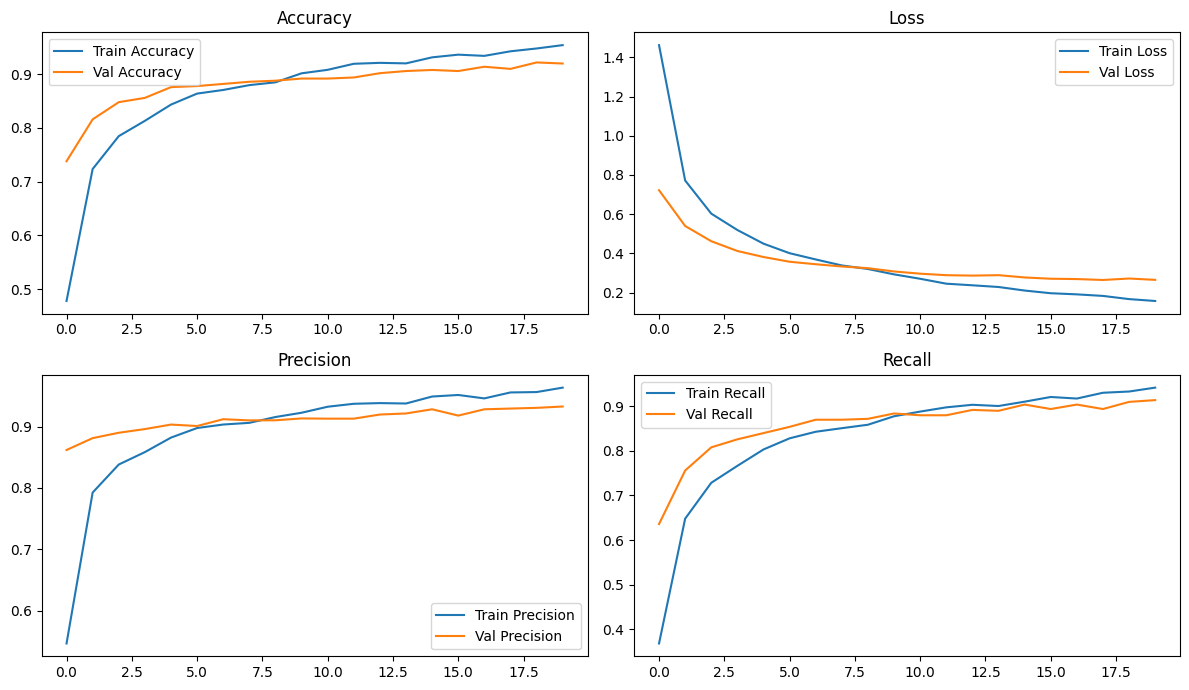

In [12]:
plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.legend()
plt.title("Precision")

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

Evaluate on Test Set

In [13]:
test_generator.reset()
results = model.evaluate(test_generator, return_dict=True)

16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9140 - loss: 0.2671 - precision: 0.9274 - recall: 0.8940


16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
              precision    recall  f1-score   support

       glass       0.92      0.94      0.93       100
       metal       0.89      0.85      0.87       100
       paper       0.90      0.93      0.92       100
     plastic       0.90      0.95      0.93       100
    residual       0.96      0.90      0.93       100

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



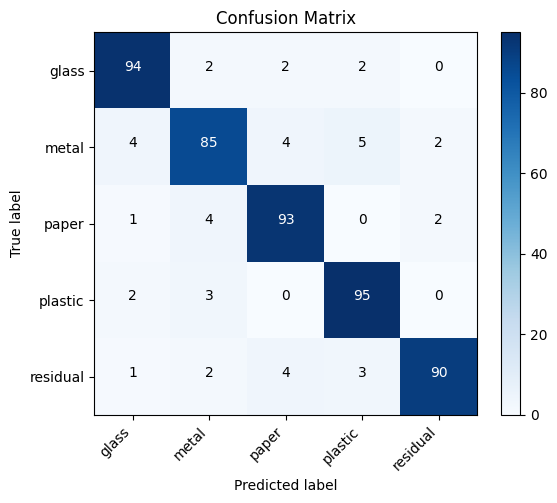

In [19]:
# Predict on test set
test_generator.reset()
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

Save Model

In [20]:
model.save("model/stage2_mobilenetv3_1.keras")